# Neural Network

## Linear Regression

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

### Generate Data

In [3]:
x_data = torch.Tensor([1, 2, 3, 4, 5])
y_data = torch.Tensor([2, 4, 6, 8, 10])

x = x_data.view(5, 1)
y = y_data.view(5, 1)

print("x :", x)
print("y :", y)

x : tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])
y : tensor([[ 2.],
        [ 4.],
        [ 6.],
        [ 8.],
        [10.]])


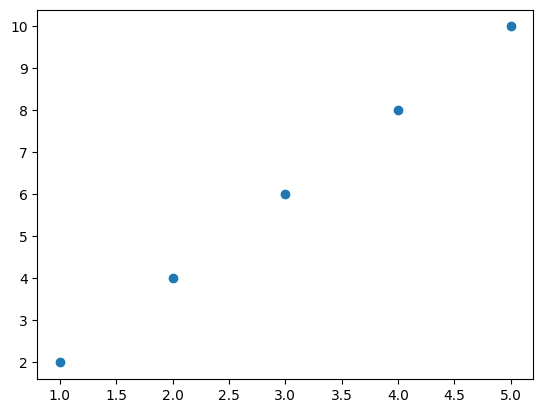

In [4]:
plt.scatter(x.numpy(), y.numpy())
plt.show()

### Derive Normal Equation

In [5]:
xtx = torch.mm(x.t(),x)
xtx_inv = xtx.inverse()
xtx_inv_xt = torch.mm(xtx_inv, x.t())

In [6]:
w = torch.mm(xtx_inv_xt, y)
w.item()

1.9999998807907104

### Define Model with Grad, nn.loss

In [7]:
w = torch.rand(1,1)
w.item()

0.9111922979354858

In [8]:
w*x

tensor([[0.9112],
        [1.8224],
        [2.7336],
        [3.6448],
        [4.5560]])

### Training

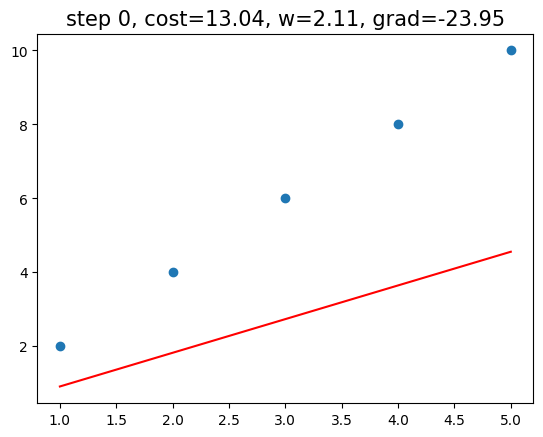

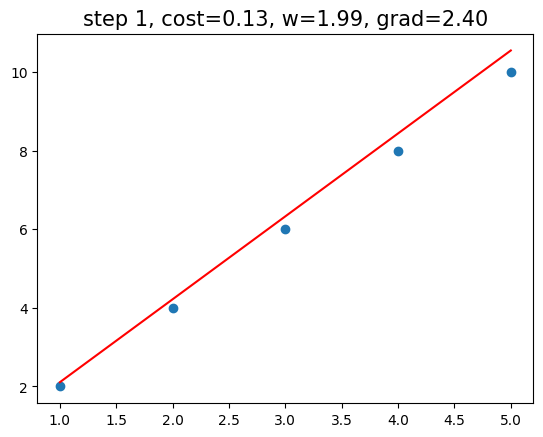

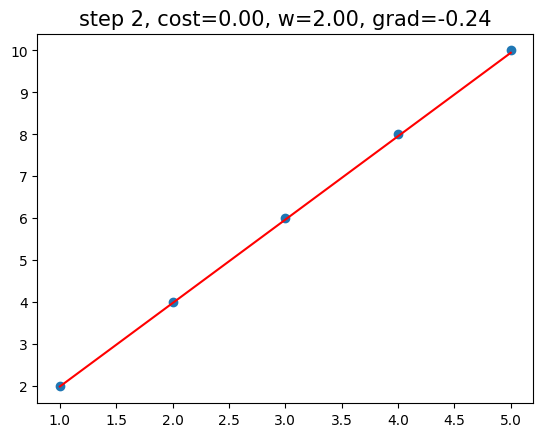

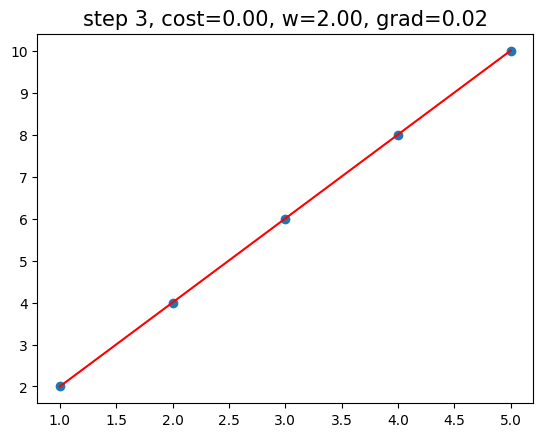

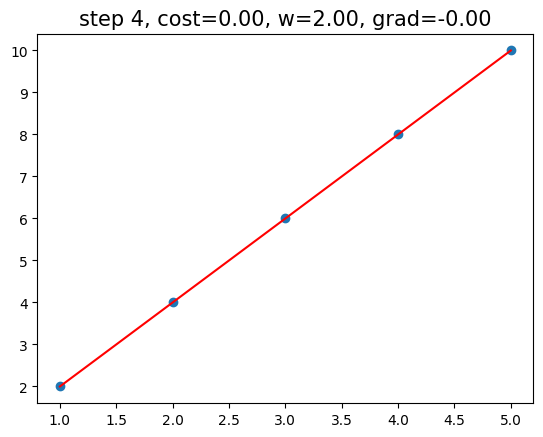

In [9]:
lr = 0.05

for step in range(5):
    pre = w*x
    cost = ((pre - y) ** 2).sum() / len(x)
    # (wx-y)^2 의 w 에 대한 미분: 2(wx-y)·x
    # d/dw of (wx-y)^2 is 2*(wx-y)*x
    grad = 2*(pre-y).view(5).dot(x.view(5))/len(x)
    w -= lr*grad
    
    plt.scatter(x.numpy(), y.numpy())
    plt.plot(x.numpy(), pre.numpy(), 'r-')
    # w.size() = 1×1, grad.size() = 1
    # w.size() = 1×1, grad.size() = 1
    plt.title('step %d, cost=%.2f, w=%.2f, grad=%4.2f' % (step, cost.item(), w.item(), grad.item()), fontdict={'size':15})
    plt.show()


In [10]:
x_new = torch.Tensor([6])
y_new = w*x_new
y_new.item()

12.000065803527832

### Define Model with nn.Linear, Optimizer

In [11]:
model = nn.Linear(1, 1, bias = False)
model.weight

Parameter containing:
tensor([[-0.9674]], requires_grad=True)

In [12]:
loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

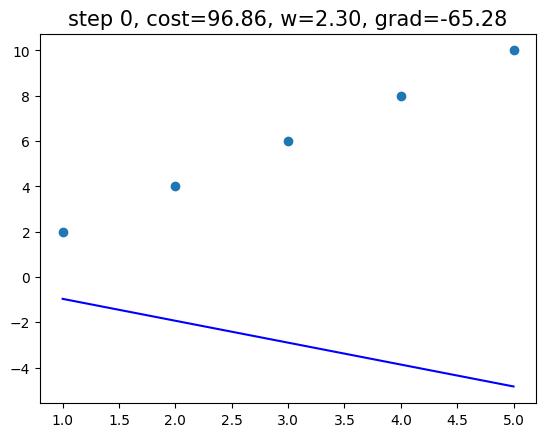

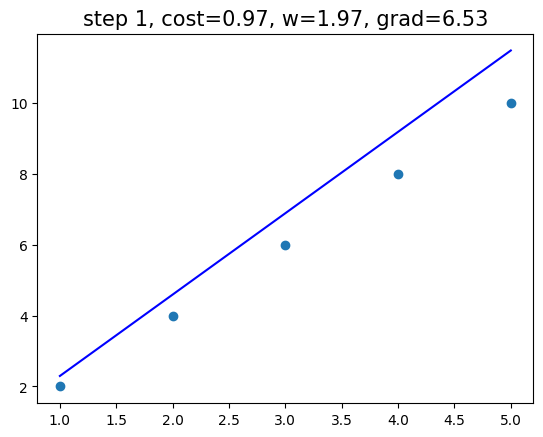

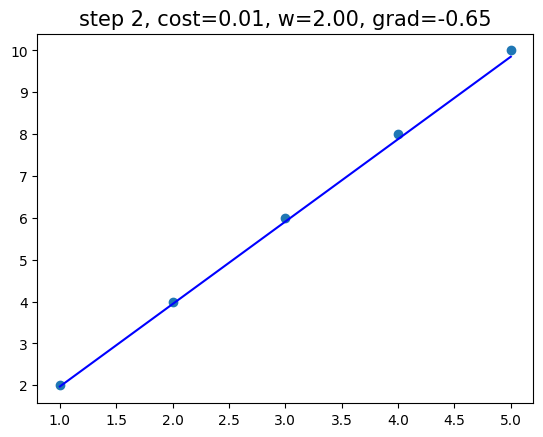

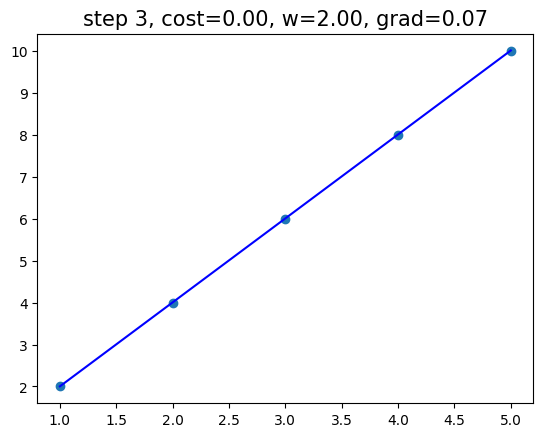

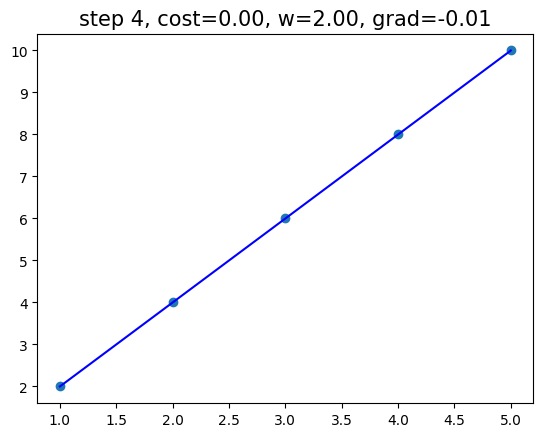

In [13]:
for step in range(5):
    pre = model(x)
    cost = loss(pre, y)
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
    
    plt.scatter(x.numpy(), y.numpy())
    # requires_grad=True 인 텐서는 numpy()를 바로 호출할 수 없음
    # A tensor with requires_grad cannot call numpy() directly
    # RuntimeError: requires_grad가 True인 변수에 numpy() 호출 불가
    # RuntimeError: Can't call numpy() on a tensor that requires grad
    plt.plot(x.numpy(), pre.detach().numpy(), 'b-')
    plt.title('step %d, cost=%.2f, w=%.2f, grad=%4.2f' 
              % (step, cost.item() ,model.weight.item(), model.weight.grad.item()), fontdict={'size':15})
    plt.show()

In [14]:
x_new = torch.Tensor([6])
y_new = model(x_new)
y_new.item()

12.000177383422852

## Activation Functions

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

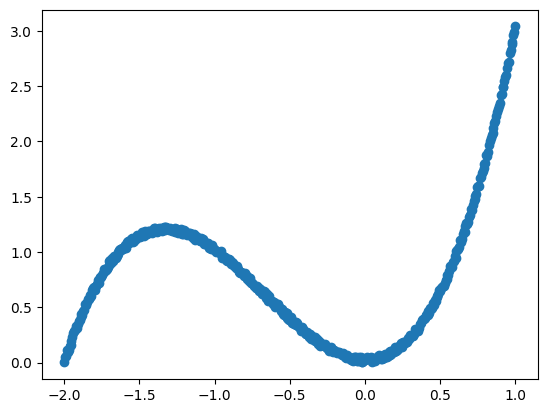

In [25]:
x = torch.linspace(-2, 1, 500)
y = x.pow(3) + 2*x.pow(2) + 0.05*torch.rand(x.size())

plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()

In [26]:
x.shape, y.shape

(torch.Size([500]), torch.Size([500]))

In [27]:
x = torch.unsqueeze(x, dim=1)
y = torch.unsqueeze(y, dim=1)

In [28]:
x.shape, y.shape

(torch.Size([500, 1]), torch.Size([500, 1]))

### Define & Train Linear Model

In [29]:
hidden = nn.Linear(1, 10, bias=True)
output = nn.Linear(10, 1, bias=True)

In [30]:
model = nn.Sequential(hidden, output)

In [31]:
loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

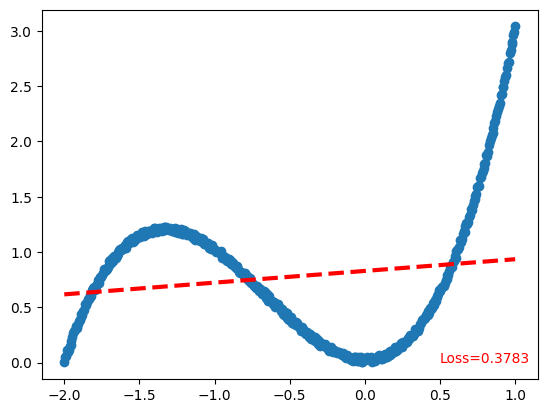

In [32]:
for step in range(500):
    pre = model(x)
    cost = loss(pre, y)
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
    
plt.scatter(x.data.numpy(), y.data.numpy())
plt.plot(x.data.numpy(), pre.data.numpy(), 'r--', lw=3)
plt.text(0.5, 0, 'Loss=%.4f' % cost.item(), fontdict={'size':10, 'color':'red'})
plt.show()

### Define & Train NonLinear Model

In [33]:
hidden = nn.Linear(1, 10, bias=True)
activation = nn.ReLU()
output = nn.Linear(10, 1, bias=True)

In [34]:
model = nn.Sequential(hidden, activation, output)

In [35]:
loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

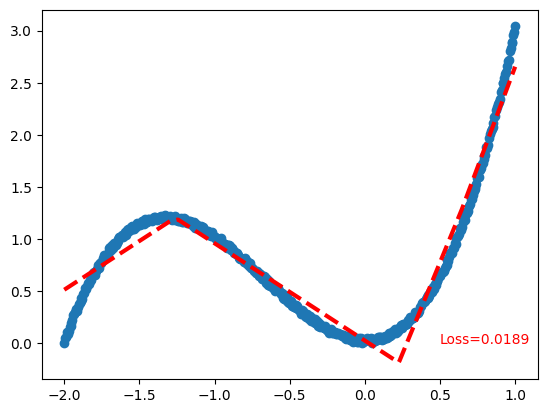

In [36]:
for step in range(500):
    pre = model(x)
    cost = loss(pre, y)
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
    
plt.scatter(x.data.numpy(), y.data.numpy())
plt.plot(x.data.numpy(), pre.data.numpy(), 'r--', lw=3)
plt.text(0.5, 0, 'Loss=%.4f' % cost.item(), fontdict={'size':10, 'color':'red'})
plt.show()

입력 $x_1=2, x_2=1$, 가중치 $w_1=5, w_2=6$ 으로 $\hat{y} = w_1 x_1 + w_2 x_2$ 를 계산하는 작은 그래프가 있다.
손실 $L$ 에 대해 $\partial L/\partial \hat{y} = 1$ 일 때, 네 개의 입력측 기울기
$\partial L/\partial x_1,\, \partial L/\partial w_1,\, \partial L/\partial x_2,\, \partial L/\partial w_2$
의 **합**을 구하라.

Problem (paraphrased): a small computation graph computes $\hat{y} = w_1 x_1 + w_2 x_2$ with $x_1=2, x_2=1$ and $w_1=5, w_2=6$.
Given $\partial L/\partial \hat{y} = 1$, find the **sum** of the four input-side gradients.


In [37]:
# 구성: x = [x1, x2] = [2, 1], W = [w1, w2] = [5, 6], bias = False
# Setup: x = [x1, x2] = [2, 1], W = [w1, w2] = [5, 6], no bias
import torch
import torch.nn as nn

# 입력 텐서 (1, 2) — requires_grad=True 로 두어 입력에 대한 기울기도 계산
# Input tensor of shape (1, 2). requires_grad=True so we also get gradients w.r.t. x
x = torch.tensor([[2., 1.]], requires_grad=True)

# nn.Linear(in=2, out=1, bias=False) 로 곱셈+합 게이트를 동시에 표현
# nn.Linear(in=2, out=1, bias=False) represents the multiply+add graph
linear = nn.Linear(2, 1, bias=False)

# 가중치를 문제 조건과 일치하도록 강제 설정
# Force the weights to match the problem
linear.weight.data = torch.tensor([[5., 6.]])
linear.weight.data


tensor([[5., 6.]])

In [38]:
# 순전파: y_hat = w1*x1 + w2*x2 = 5*2 + 6*1 = 16
# Forward pass: y_hat = w1*x1 + w2*x2 = 16
y_hat = linear(x)
print("y_hat =", y_hat.item())


y_hat = 16.0


In [39]:
# 역전파: ∂L/∂y_hat = 1 가정 → y_hat.sum().backward() 와 동치
# Backward with ∂L/∂y_hat = 1 (equivalent to .sum().backward())
y_hat.sum().backward()

print("∂L/∂W =", linear.weight.grad)   # [x1, x2] = [2, 1]
print("∂L/∂x =", x.grad)               # [w1, w2] = [5, 6]

# 네 개의 합 = 5 + 2 + 6 + 1 = 14
# Sum of the four = 5 + 2 + 6 + 1 = 14
total = linear.weight.grad.sum().item() + x.grad.sum().item()
print("Sum of all four =", total)
assert total == 14.0, "예상 값 14 와 다름 / Mismatch with expected 14"


∂L/∂W = tensor([[2., 1.]])
∂L/∂x = tensor([[5., 6.]])
Sum of all four = 14.0
